In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
train_df = pd.read_parquet('train_final.parquet')
test_df = pd.read_parquet('test_final.parquet')

In [3]:
train_df.drop('Fwd Header Length.1',inplace=True,axis=1)
test_df.drop('Fwd Header Length.1',inplace=True,axis=1)

In [4]:
for col in train_df.columns:
    col_type = train_df[col].dtype
    if col_type != object:
        c_min = train_df[col].min()
        c_max = train_df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            train_df[col] = train_df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            train_df[col] = train_df[col].astype(np.int32)

In [5]:
for col in test_df.columns:
    col_type = test_df[col].dtype
    if col_type != object:
        c_min = test_df[col].min()
        c_max = test_df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            test_df[col] = test_df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            test_df[col] = test_df[col].astype(np.int32)

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1975710 entries, 0 to 1975709
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int32  
 1   Flow Duration                int32  
 2   Total Fwd Packets            int32  
 3   Total Backward Packets       int32  
 4   Total Length of Fwd Packets  int32  
 5   Total Length of Bwd Packets  int32  
 6   Fwd Packet Length Max        int32  
 7   Fwd Packet Length Min        int32  
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        int32  
 11  Bwd Packet Length Min        int32  
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 float32
 18  Flow IAT Max                 int32  
 19  

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580742 entries, 0 to 580741
Data columns (total 78 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             580742 non-null  int32  
 1   Flow Duration                580742 non-null  int32  
 2   Total Fwd Packets            580742 non-null  int32  
 3   Total Backward Packets       580742 non-null  int32  
 4   Total Length of Fwd Packets  580742 non-null  int32  
 5   Total Length of Bwd Packets  580742 non-null  int32  
 6   Fwd Packet Length Max        580742 non-null  int32  
 7   Fwd Packet Length Min        580742 non-null  int32  
 8   Fwd Packet Length Mean       580742 non-null  float32
 9   Fwd Packet Length Std        580742 non-null  float32
 10  Bwd Packet Length Max        580742 non-null  int32  
 11  Bwd Packet Length Min        580742 non-null  int32  
 12  Bwd Packet Length Mean       580742 non-null  float32
 13 

In [8]:
train_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack
count,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,...,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1975710.0,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06
mean,8.712304e+03,1.748946e+07,1.082514e+01,1.221479e+01,5.761576e+02,1.938103e+04,2.049473e+02,1.817284e+01,5.430517e+01,6.548643e+01,...,-3.939495e+03,8.511727e+04,4.877460e+04,1.692024e+05,5.743061e+04,10144401.0,3.495007e+05,1.042352e+07,9.849848e+06,5.062271e-01
std,1.916438e+04,3.620110e+07,8.297731e+02,1.101498e+03,1.108664e+04,2.504963e+06,5.279374e+02,3.789843e+01,1.278147e+02,1.818044e+02,...,1.298714e+06,6.506464e+05,4.241799e+05,1.079466e+06,5.743389e+05,26193146.0,3.600280e+06,2.676999e+07,2.618644e+07,1.334754e+00
min,0.000000e+00,-4.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.100000e+02,2.000000e+00,1.000000e+00,1.800000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,4.917200e+04,2.000000e+00,2.000000e+00,7.000000e+01,1.630000e+02,4.200000e+01,2.000000e+00,3.800000e+01,0.000000e+00,...,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.375276e+06,6.000000e+00,5.000000e+00,3.520000e+02,1.090000e+03,2.740000e+02,3.800000e+01,5.371429e+01,8.756538e+01,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.293000e+03,5.939286e+03,7.125597e+03,...,1.380000e+02,1.070000e+08,7.420000e+07,1.070000e+08,1.070000e+08,120000000.0,7.690000e+07,1.200000e+08,1.200000e+08,6.000000e+00


In [9]:
train_df['Attack'].value_counts()

Attack
0    1720966
4     189135
3      29999
5      25501
2       7417
6       1718
1        974
Name: count, dtype: int64

In [10]:
num_unique = train_df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
train_df = train_df[not_one_variable]
test_df = test_df[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [11]:
train_df.shape

(1975710, 70)

In [13]:
features_train = train_df.drop('Attack', axis = 1)
attacks_train = train_df['Attack']
features_test = test_df.drop('Attack', axis
 = 1)
attacks_test = test_df['Attack']

For Unsupervised Models

In [14]:
# train_df_unsupervised = train_df.copy(deep=True)
# test_df_unsupervised = test_df.copy(deep=True)


from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()

scaled_features_train_unsupervised = minmax_scaler.fit_transform(features_train)
scaled_features_test_unsupervised = minmax_scaler.transform(features_test)


In [15]:
joblib.dump(minmax_scaler,r"scalers/minmaxscaler.joblib")

['scalers/minmaxscaler.joblib']

In [18]:
train_unsupervised = pd.DataFrame(
    scaled_features_train_unsupervised,
    columns=features_train.columns,
    index=features_train.index
)
test_unsupervised = pd.DataFrame(
    scaled_features_test_unsupervised,
    columns=features_test.columns,
    index=features_test.index
)
train_unsupervised['Attack'] = attacks_train

test_unsupervised['Attack'] = attacks_test


In [19]:
# Friday Attacks 1: Bot 3:DDos 5: PortScan
train_unsupervised = train_unsupervised[~train_unsupervised['Attack'].isin([1,3,5])]
# Rest is in Mon to Thu and BENIGN Is 0
test_unsupervised = test_unsupervised[~test_unsupervised['Attack'].isin([2,4,6])]

In [21]:
train_unsupervised.shape

(1919236, 70)

In [22]:
train_unsupervised.to_parquet(r'final/train_us.parquet')
test_unsupervised.to_parquet(r'final/test_us.parquet')

For Supervised Models

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

scaled_features_train = scaler.fit_transform(features_train)
scaled_features_test = scaler.transform(features_test)

In [235]:
joblib.dump(scaler,r"scalers\standardscaler.joblib")

['scalers\\standardscaler.joblib']

In [236]:
print(f"Features Shape Train: f{features_train.shape}")
print(f"Attacks Shape Train: f{attacks_train.shape}")
print(f"Features Shape Test: f{features_test.shape}")
print(f"Attacks Shape Test: f{attacks_test.shape}")

Features Shape Train: f(1975710, 69)
Attacks Shape Train: f(1975710,)
Features Shape Test: f(580742, 69)
Attacks Shape Test: f(580742,)


In [237]:
from sklearn.decomposition import IncrementalPCA

size = len(features_train.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features_train, len(features_train) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

information retained: 98.97%


In [238]:
# ipca = joblib.load(r"scalers\incrementail_pca_model.joblib")

In [239]:
transformed_features_train = ipca.transform(scaled_features_train)
transformed_features_test = ipca.transform(scaled_features_test)
new_data_train = pd.DataFrame(transformed_features_train, columns = [f'PC{i+1}' for i in range(size)])
new_data_test = pd.DataFrame(transformed_features_test, columns = [f'PC{i+1}' for i in range(size)])
new_data_train['Attack'] = attacks_train.values
new_data_test['Attack'] = attacks_test.values

In [240]:
joblib.dump(ipca,r"scalers\incrementail_pca_model.joblib")

['scalers\\incrementail_pca_model.joblib']

In [241]:
new_data_train

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,Attack
0,1.208802,0.234786,-2.655242,0.683666,-0.121411,-0.094553,-1.273503,-1.120861,0.323344,-0.186611,...,-0.039556,-0.870772,-0.137350,0.792820,-0.120318,-0.069270,-0.077878,0.063831,-0.025269,4
1,-1.989039,-0.056202,0.204666,-0.686079,0.642564,0.389450,-0.349293,0.197580,-0.147723,-0.007077,...,-0.046705,-0.315083,-0.259181,-0.783580,-0.898445,-0.034753,-0.067893,0.182043,-0.115440,4
2,-1.574430,-0.011603,-0.053697,0.301405,0.434055,1.359221,-1.779325,0.091420,0.222754,-0.075224,...,-0.447693,-0.666313,-0.242116,0.659885,-0.093238,-0.265243,0.012115,-0.136698,0.120370,4
3,-0.198642,0.237901,-1.570355,1.807515,0.172206,-0.435863,-1.289602,-0.357675,0.288467,-0.133384,...,-0.293437,-0.689351,0.224831,0.954030,-0.510553,-0.253497,0.104768,-0.224627,0.160110,4
4,-1.989242,-0.056210,0.204759,-0.686541,0.644365,0.388623,-0.348138,0.197196,-0.147151,-0.006874,...,-0.046728,-0.314960,-0.259961,-0.783403,-0.898783,-0.034943,-0.067817,0.181992,-0.115436,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975705,-1.893028,-0.060280,0.268199,-0.687264,0.625609,0.403655,-0.365445,0.208369,-0.163300,-0.006640,...,-0.061872,-0.308324,-0.250759,-0.773009,-0.862759,-0.051861,-0.055889,0.156927,-0.094355,3
1975706,7.703992,0.379179,-8.456708,-3.679983,-2.099403,-0.086719,-0.685795,-5.124013,-0.126994,-0.588425,...,0.507923,-1.329042,-0.423649,-0.507234,0.066560,-0.356979,0.211103,-0.344155,0.227779,3
1975707,10.372623,0.397627,-3.090078,-0.743395,0.917522,6.006258,6.297407,-4.362306,-2.585980,-0.256839,...,0.443499,-0.082441,-0.508542,-0.672531,-0.038634,-0.259785,0.158028,-0.011076,-0.019906,3
1975708,6.447138,-0.223346,-0.765794,-2.371417,0.609897,1.118669,1.214086,-0.676034,-0.516295,0.097103,...,-0.671532,1.144031,0.910587,0.257187,-1.345644,0.405992,0.045082,-0.036363,0.048831,3


In [242]:
new_data_test

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,Attack
0,0.396532,-0.016764,0.736349,1.654251,0.287301,1.398947,-1.625579,0.762095,0.829726,0.001612,...,-0.348643,0.051472,0.197045,-0.352285,0.819116,-0.399501,0.063066,-0.209173,0.157888,1
1,-2.205149,-0.072442,0.336514,-1.112137,0.983787,0.553186,-0.809378,0.928295,-1.050081,-0.192730,...,-0.035852,0.024614,-1.393375,0.497188,-0.745423,-0.277918,0.032452,0.030859,-0.051113,1
2,-1.606209,0.069591,-0.582883,0.733004,0.294969,0.661448,-1.308324,-0.134445,0.428145,-0.042611,...,-0.376428,-0.701140,0.256263,0.919610,0.245813,-0.088449,-0.094466,0.010953,0.026431,1
3,0.205208,0.512497,-2.800189,5.444278,1.063315,-3.244675,-1.796728,-0.024924,-0.375139,-0.350993,...,-0.107866,-0.148162,-0.324698,0.920478,0.313344,0.259164,-0.113511,0.220005,-0.120325,1
4,-2.225342,-0.071960,0.350683,-1.100207,0.899057,0.403997,-0.615672,0.897614,-1.022706,-0.172938,...,-0.008587,0.036439,-1.602765,0.498189,-0.912150,-0.252566,0.053514,0.012274,-0.038091,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580737,-0.820353,0.238460,-1.026628,1.603303,-0.024363,0.460211,-1.664161,-0.130976,0.446495,-0.117648,...,-0.391652,-0.079806,-0.191300,-0.121524,0.593175,-0.186580,-0.093332,0.107418,-0.074713,2
580738,-0.788897,0.237154,-1.006463,1.619160,-0.019191,0.471900,-1.665104,-0.107092,0.457879,-0.115359,...,-0.389373,-0.073042,-0.189567,-0.131001,0.589885,-0.190679,-0.089498,0.101992,-0.071292,2
580739,-0.840388,0.236054,-1.009203,1.548680,-0.029151,0.512478,-1.666068,-0.132836,0.457758,-0.114574,...,-0.385450,-0.077438,-0.201581,-0.123759,0.609066,-0.158202,-0.112903,0.134937,-0.090881,2
580740,-2.109327,-0.059152,0.700205,-0.972366,3.397734,-0.861290,1.312915,-1.234437,0.894928,0.158974,...,-0.251555,-0.139735,-0.709327,-0.074933,-0.511820,-0.028229,-0.022857,0.068889,-0.046913,2


In [243]:
new_data_train.to_parquet(r'new_data_train.parquet')
new_data_test.to_parquet(r'new_data_test.parquet')

In [2]:
df1 = pd.read_parquet('new_data_train.parquet')
df1.describe()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,Attack
count,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,...,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06,1.975710e+06
mean,-1.048190e-15,1.119197e-17,5.662159e-16,4.743785e-16,5.579298e-16,-1.302757e-16,-3.212729e-16,-1.613946e-15,-1.044277e-15,-2.358658e-16,...,1.811932e-15,-4.131995e-15,-3.180074e-16,-2.710816e-16,2.503664e-16,3.351550e-16,3.612935e-17,-3.029960e-16,2.536607e-16,5.062271e-01
std,4.016496e+00,2.669901e+00,2.371873e+00,2.039780e+00,1.970139e+00,1.727006e+00,1.553112e+00,1.481864e+00,1.418904e+00,1.412055e+00,...,6.797215e-01,6.285083e-01,5.902521e-01,5.551888e-01,5.114209e-01,4.427264e-01,4.496193e-01,3.992631e-01,3.980615e-01,1.334754e+00
min,-4.597130e+00,-4.063996e+00,-3.441267e+01,-6.182301e+01,-6.740620e+01,-1.286862e+02,-2.240031e+01,-5.207970e+01,-2.133706e+02,-5.223521e+01,...,-5.295887e+01,-4.217416e+01,-1.042739e+01,-7.407594e+01,-1.216084e+01,-2.872468e+01,-1.740363e+02,-1.609253e+02,-2.016056e+02,0.000000e+00
25%,-2.080991e+00,-6.286246e-02,-2.019418e-01,-8.865557e-01,-1.561784e+00,-5.048971e-01,-9.517498e-01,-3.245602e-01,-1.461375e-01,-1.262627e-01,...,-2.963389e-01,-2.229341e-01,-2.000401e-01,-2.392960e-01,-1.614453e-01,-1.907666e-01,-6.229954e-02,-8.670843e-02,-5.788949e-02,0.000000e+00
50%,-1.998833e+00,-3.867698e-02,2.203370e-01,-1.330395e-01,-1.020374e-01,-1.991960e-01,3.737019e-01,8.394334e-02,6.080368e-02,3.637212e-02,...,-2.411519e-02,-3.878524e-02,-5.538614e-02,-2.138655e-02,3.966339e-02,2.776848e-02,5.457720e-03,-1.205088e-02,9.439457e-03,0.000000e+00
75%,2.802562e-01,2.477305e-03,3.019006e-01,2.010411e-01,8.319857e-01,5.264788e-01,7.574326e-01,2.397157e-01,3.523141e-01,6.349182e-02,...,2.031149e-01,1.386327e-01,1.683989e-01,3.535584e-01,1.942793e-01,1.900882e-01,5.472399e-02,7.782639e-02,6.034661e-02,0.000000e+00
max,4.442517e+01,7.284523e+02,6.153341e+01,2.957556e+02,7.241565e+01,1.318729e+02,1.357245e+02,2.592038e+01,1.857230e+02,8.015539e+01,...,2.759218e+01,2.021382e+01,9.322193e+00,8.406076e+00,3.334625e+01,2.063923e+01,5.811784e+01,1.618133e+02,1.953120e+02,6.000000e+00


Balanced Dataset for binary Clasification

In [244]:
new_data_train['Attack'].value_counts()

Attack
0    1720966
4     189135
3      29999
5      25501
2       7417
6       1718
1        974
Name: count, dtype: int64

In [245]:
normal_traffic_train = new_data_train.loc[new_data_train['Attack'] == 0]
intrusions_train = new_data_train.loc[new_data_train['Attack'] != 0]

In [246]:
print(f"Normal Train Count: {len(normal_traffic_train)}")
print(f"Intrusions Train Count: {len(intrusions_train)}")

Normal Train Count: 1720966
Intrusions Train Count: 254744


In [247]:
normal_traffic_train = normal_traffic_train.sample(n = len(intrusions_train), replace = False, random_state=42)
ids_data_train = pd.concat([intrusions_train, normal_traffic_train])
ids_data_train['Attack'] = np.where((ids_data_train['Attack'] == 0), 0, 1)
bc_data_train = ids_data_train
# bc_data_train = ids_data_train.sample(n=100000,random_state=42) 

In [248]:

print("Distribution for Training Subset (bc_data_train):")
print(bc_data_train['Attack'].value_counts())

Distribution for Training Subset (bc_data_train):
Attack
1    254744
0    254744
Name: count, dtype: int64


In [249]:
train_unique_attacks = bc_data_train['Attack'].value_counts().tolist()
train_unique_attacks_names = bc_data_train['Attack'].value_counts().index
train_unique_attacks_names = train_unique_attacks_names.astype(str)

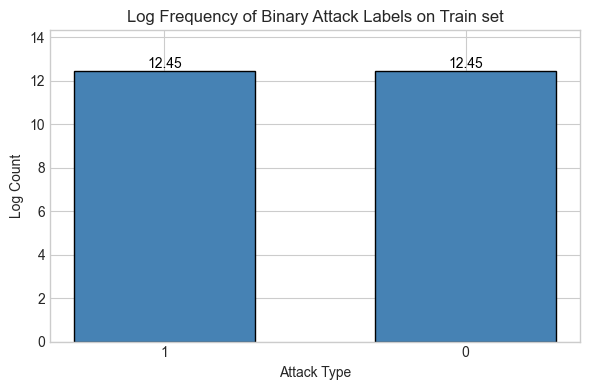

In [250]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6, 4))
bars = plt.bar(
    train_unique_attacks_names,
    np.log(train_unique_attacks),
    color="steelblue",
    edgecolor="black",
    width=0.6
)

for bar, value in zip(bars, np.log(train_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Binary Attack Labels on Train set")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()


In [251]:
normal_traffic_test = new_data_test.loc[new_data_test['Attack'] == 0]
intrusions_test = new_data_test.loc[new_data_test['Attack'] != 0]
print(f"Normal Test Count: {len(normal_traffic_test)}")
print(f"Intrusions Test Count: {len(intrusions_test)}")

Normal Test Count: 395106
Intrusions Test Count: 185636


In [252]:
normal_traffic_test = normal_traffic_test.sample(n = len(intrusions_test), replace = False, random_state=42)

ids_data_test = pd.concat([intrusions_test, normal_traffic_test])
ids_data_test['Attack'] = np.where((ids_data_test['Attack'] == 0), 0, 1)
bc_data_test = ids_data_test

# bc_data_test = ids_data_test.sample(n=15000,random_state=42) 

print("Distribution for Balanced Test Set (bc_data_test):")
print(bc_data_test['Attack'].value_counts())

Distribution for Balanced Test Set (bc_data_test):
Attack
1    185636
0    185636
Name: count, dtype: int64


In [253]:
test_unique_attacks = bc_data_test['Attack'].value_counts().tolist()
test_unique_attacks_names = bc_data_test['Attack'].value_counts().index
test_unique_attacks_names = test_unique_attacks_names.astype(str)

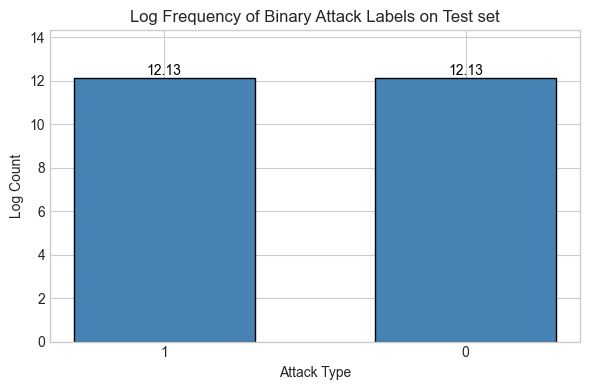

In [254]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6, 4))
bars = plt.bar(
    test_unique_attacks_names,
    np.log(test_unique_attacks),
    color="steelblue",
    edgecolor="black",
    width=0.6
)

for bar, value in zip(bars, np.log(test_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of Binary Attack Labels on Test set")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()


In [255]:
bc_data_train.to_parquet(r'final\train_bc.parquet')
bc_data_test.to_parquet(r'final\test_bc.parquet')

In [256]:
bc_data_train

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,Attack
0,1.208802,0.234786,-2.655242,0.683666,-0.121411,-0.094553,-1.273503,-1.120861,0.323344,-0.186611,...,-0.039556,-0.870772,-0.137350,0.792820,-0.120318,-0.069270,-0.077878,0.063831,-0.025269,1
1,-1.989039,-0.056202,0.204666,-0.686079,0.642564,0.389450,-0.349293,0.197580,-0.147723,-0.007077,...,-0.046705,-0.315083,-0.259181,-0.783580,-0.898445,-0.034753,-0.067893,0.182043,-0.115440,1
2,-1.574430,-0.011603,-0.053697,0.301405,0.434055,1.359221,-1.779325,0.091420,0.222754,-0.075224,...,-0.447693,-0.666313,-0.242116,0.659885,-0.093238,-0.265243,0.012115,-0.136698,0.120370,1
3,-0.198642,0.237901,-1.570355,1.807515,0.172206,-0.435863,-1.289602,-0.357675,0.288467,-0.133384,...,-0.293437,-0.689351,0.224831,0.954030,-0.510553,-0.253497,0.104768,-0.224627,0.160110,1
4,-1.989242,-0.056210,0.204759,-0.686541,0.644365,0.388623,-0.348138,0.197196,-0.147151,-0.006874,...,-0.046728,-0.314960,-0.259961,-0.783403,-0.898783,-0.034943,-0.067817,0.181992,-0.115436,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230231,-0.246743,-0.173713,1.619518,-0.201130,0.491637,0.748544,-0.385736,1.049021,-0.027010,0.026280,...,-0.396285,-0.172881,-0.172726,-1.500754,-0.654217,-0.515833,0.029025,0.018704,-0.005649,0
1692198,-1.957116,-0.038412,0.154467,-0.244175,-2.084408,-0.592735,1.045439,-0.051557,0.085823,0.078119,...,1.189542,0.402049,0.253723,0.270760,0.014902,-0.551114,-0.090453,0.195799,-0.167530,0
1200255,-2.050804,-0.037086,0.232259,-0.098924,-1.714453,-0.416956,0.700545,0.085994,0.055425,0.056431,...,0.018569,-0.032310,-0.075281,-0.112773,0.048876,0.088430,0.034146,-0.045796,0.026757,0
912459,-2.043562,-0.037738,0.636698,-0.673627,3.122317,-1.293613,1.543802,-1.294491,0.817337,0.149242,...,-0.711610,-0.214383,-0.612576,-0.071643,-0.578231,-0.349532,-0.132216,0.256867,-0.184546,0


In [257]:
bc_data_test

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,Attack
0,0.396532,-0.016764,0.736349,1.654251,0.287301,1.398947,-1.625579,0.762095,0.829726,0.001612,...,-0.348643,0.051472,0.197045,-0.352285,0.819116,-0.399501,0.063066,-0.209173,0.157888,1
1,-2.205149,-0.072442,0.336514,-1.112137,0.983787,0.553186,-0.809378,0.928295,-1.050081,-0.192730,...,-0.035852,0.024614,-1.393375,0.497188,-0.745423,-0.277918,0.032452,0.030859,-0.051113,1
2,-1.606209,0.069591,-0.582883,0.733004,0.294969,0.661448,-1.308324,-0.134445,0.428145,-0.042611,...,-0.376428,-0.701140,0.256263,0.919610,0.245813,-0.088449,-0.094466,0.010953,0.026431,1
3,0.205208,0.512497,-2.800189,5.444278,1.063315,-3.244675,-1.796728,-0.024924,-0.375139,-0.350993,...,-0.107866,-0.148162,-0.324698,0.920478,0.313344,0.259164,-0.113511,0.220005,-0.120325,1
4,-2.225342,-0.071960,0.350683,-1.100207,0.899057,0.403997,-0.615672,0.897614,-1.022706,-0.172938,...,-0.008587,0.036439,-1.602765,0.498189,-0.912150,-0.252566,0.053514,0.012274,-0.038091,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561951,-1.962214,0.012451,0.403238,-0.558512,4.272925,-1.766051,1.346973,-0.930310,0.357496,0.059474,...,-0.094406,-0.040306,1.305232,0.178865,0.832196,0.474527,-0.066424,-0.011106,0.062152,0
399416,-2.062159,-0.039413,0.251026,-0.045227,-1.832569,-0.539006,0.807465,0.060481,0.042555,0.059328,...,-0.080353,-0.057055,-0.093381,-0.121752,0.061527,0.203217,0.052994,-0.086785,0.063479,0
262788,-1.990082,-0.039334,0.166388,-0.250498,-1.670234,-0.320184,0.695241,0.059587,0.086318,0.061718,...,0.664032,0.187295,0.100249,0.062366,-0.000021,-0.346415,-0.044264,0.114592,-0.108093,0
362878,-1.939590,-0.019877,0.132549,0.086616,-1.680455,-0.606304,0.692253,0.056519,0.006840,0.039746,...,-0.419678,-0.169107,-0.175332,-0.225986,0.018617,0.396385,0.101214,-0.169438,0.127360,0


BAlANCED DATA FOR MULTICLASS CLASSIFICATION

In [258]:
new_data_train['Attack'].value_counts()

Attack
0    1720966
4     189135
3      29999
5      25501
2       7417
6       1718
1        974
Name: count, dtype: int64

In [259]:

class_counts_train = new_data_train['Attack'].value_counts()


selected_classes_train = class_counts_train[class_counts_train >= 900] 
class_names_train = selected_classes_train.index

selected_train = new_data_train[new_data_train['Attack'].isin(class_names_train)] 

dfs = []
for name in class_names_train:
    df = selected_train[selected_train['Attack'] == name]

    if len(df) > 7500:
        df = df.sample(n = 8000, random_state = 42, replace = False)

    dfs.append(df)


mc_train = pd.concat(dfs, ignore_index = True)

print(mc_train['Attack'].value_counts()) 

Attack
0    8000
4    8000
3    8000
5    8000
2    7417
6    1718
1     974
Name: count, dtype: int64


In [260]:
train_unique_attacks = mc_train['Attack'].value_counts().tolist()
train_unique_attacks_names = mc_train['Attack'].value_counts().index
train_unique_attacks_names = train_unique_attacks_names.astype(str)

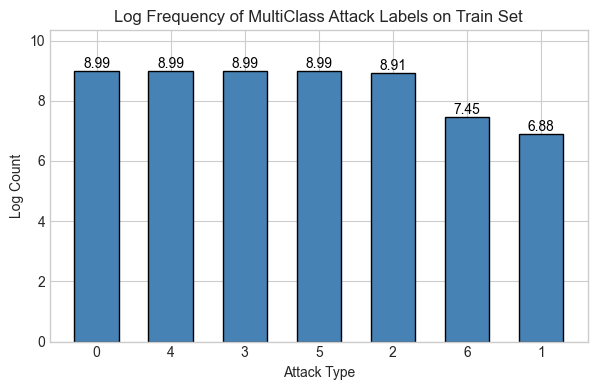

In [261]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6, 4))
bars = plt.bar(
    train_unique_attacks_names,
    np.log(train_unique_attacks),
    color="steelblue",
    edgecolor="black",
    width=0.6
)

for bar, value in zip(bars, np.log(train_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of MultiClass Attack Labels on Train Set")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()


In [262]:
new_data_test['Attack'].value_counts()

Attack
0    395106
3     98022
5     79290
4      4871
2      2039
1       981
6       433
Name: count, dtype: int64

In [263]:
MAX_SAMPLES = 5000
class_counts_test = new_data_test['Attack'].value_counts()


selected_classes_test = class_counts_test[class_counts_test >= 400]
class_names_test = selected_classes_test.index


selected_test = new_data_test[new_data_test['Attack'].isin(class_names_test)] 

dfs_test = []

for name in class_names_test:
    df_test = selected_test[selected_test['Attack'] == name]

    if len(df_test) > MAX_SAMPLES:
        df_test = df_test.sample(n = MAX_SAMPLES, random_state = 42, replace = False)

    dfs_test.append(df_test)


mc_test = pd.concat(dfs_test, ignore_index = True)


print("\nFinal Multiclass Test Data Distribution:")
print(mc_test['Attack'].value_counts())


Final Multiclass Test Data Distribution:
Attack
0    5000
3    5000
5    5000
4    4871
2    2039
1     981
6     433
Name: count, dtype: int64


In [264]:
test_unique_attacks = mc_test['Attack'].value_counts().tolist()
test_unique_attacks_names = mc_test['Attack'].value_counts().index
test_unique_attacks_names = test_unique_attacks_names.astype(str)

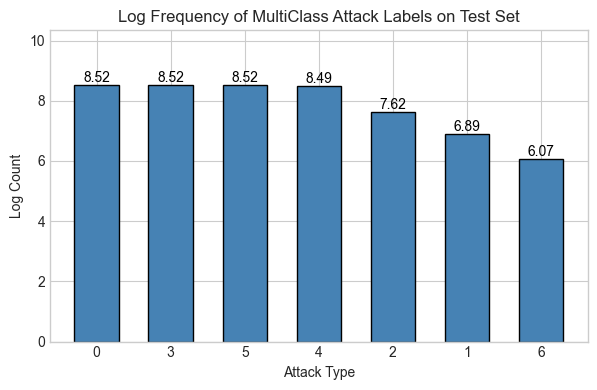

In [265]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6, 4))
bars = plt.bar(
    test_unique_attacks_names,
    np.log(test_unique_attacks),
    color="steelblue",
    edgecolor="black",
    width=0.6
)

for bar, value in zip(bars, np.log(test_unique_attacks)):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Log Frequency of MultiClass Attack Labels on Test Set")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")

plt.tight_layout()
ymax = max(np.log(train_unique_attacks))
plt.ylim(0, ymax * 1.15) 
plt.show()


In [266]:
mc_train.to_parquet(r'final\train_mc.parquet')
mc_test.to_parquet(r'final\test_mc.parquet')